✅ Eye templates directory created at /content/eye_templates/
👁️  REAL-TIME EYE DETECTION AND TEMPLATE CAPTURE

📋 Choose capture method:
1. Webcam Capture (Real-time)
2. Upload Image File
Enter your choice (1 or 2): 1

🚀 Starting webcam capture...


📸 INSTRUCTIONS:
1. Position your face in the camera
2. Make sure both eyes are clearly visible
3. Click 'Capture Eyes' button
4. Wait for processing and confirmation
5. Click 'Stop' when done

⏳ Waiting for capture...

✅ CELL 1 COMPLETED!

📝 NEXT STEPS:
1. Make sure you see 'SUCCESS! Captured and saved X eye(s)' message
2. Check that eye images are displayed above
3. Run Cell 2 for iris segmentation

💾 Your eye templates are safely saved in Colab file system!
   Location: /content/eye_templates/


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


✅ Saved 2 eye template(s) to /content/eye_templates
🎉 SUCCESS! Captured and saved 2 eye(s)


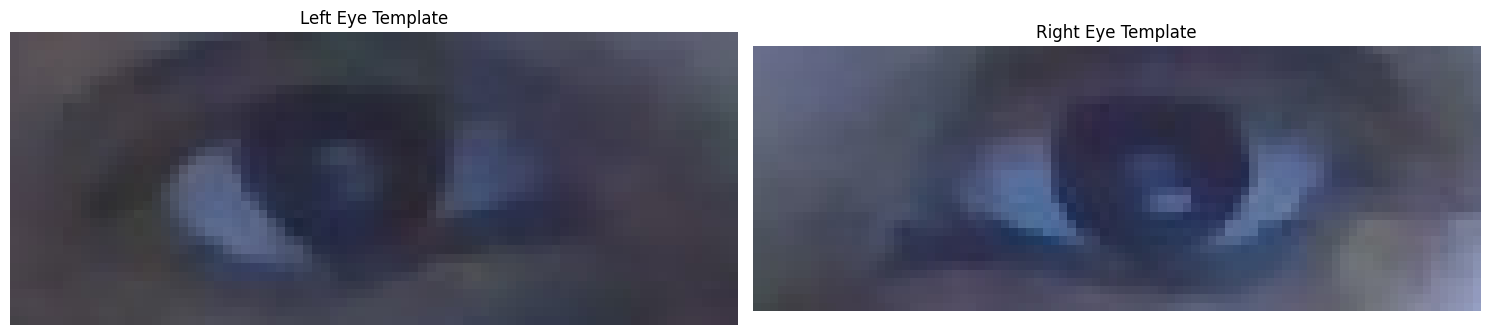


📁 Eye templates saved to Colab file system:
   Location: /content/eye_templates/
   - eye_left_1.png
   - eye_right_2.png
🛑 Webcam stopped


In [3]:
# Install required packages
!pip install opencv-python-headless mediapipe numpy Pillow

import cv2
import mediapipe as mp
import numpy as np
from PIL import Image
import os
import json
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

%matplotlib inline

# Create directory for saving eye templates
!mkdir -p /content/eye_templates

print("✅ Eye templates directory created at /content/eye_templates/")

# Initialize MediaPipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils

# Define eye regions (MediaPipe landmarks)
LEFT_EYE_INDICES = [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246]
RIGHT_EYE_INDICES = [362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398]

class EyeDetector:
    def __init__(self):
        self.face_mesh = mp_face_mesh.FaceMesh(
            max_num_faces=1,
            refine_landmarks=True,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )

    def get_eye_roi(self, landmarks, eye_indices, image_shape):
        """Extract eye region of interest"""
        h, w = image_shape[:2]
        eye_points = []

        for idx in eye_indices:
            if idx < len(landmarks.landmark):
                landmark = landmarks.landmark[idx]
                x = int(landmark.x * w)
                y = int(landmark.y * h)
                eye_points.append((x, y))

        if len(eye_points) == 0:
            return None

        # Get bounding box with padding
        x_coords = [p[0] for p in eye_points]
        y_coords = [p[1] for p in eye_points]

        x_min, x_max = min(x_coords), max(x_coords)
        y_min, y_max = min(y_coords), max(y_coords)

        # Add padding
        padding_x = int((x_max - x_min) * 0.3)
        padding_y = int((y_max - y_min) * 0.3)

        x_min = max(0, x_min - padding_x)
        x_max = min(w, x_max + padding_x)
        y_min = max(0, y_min - padding_y)
        y_max = min(h, y_max + padding_y)

        if x_max <= x_min or y_max <= y_min:
            return None

        return (x_min, y_min, x_max, y_max)

    def process_frame(self, image):
        """Process frame and detect eyes"""
        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        results = self.face_mesh.process(rgb_image)

        eye_regions = []

        if results.multi_face_landmarks:
            for face_landmarks in results.multi_face_landmarks:
                # Get left eye
                left_eye_roi = self.get_eye_roi(face_landmarks, LEFT_EYE_INDICES, image.shape)
                if left_eye_roi:
                    x_min, y_min, x_max, y_max = left_eye_roi
                    if (y_max - y_min) > 10 and (x_max - x_min) > 10:
                        left_eye = image[y_min:y_max, x_min:x_max]
                        eye_regions.append(('left', left_eye, left_eye_roi))

                # Get right eye
                right_eye_roi = self.get_eye_roi(face_landmarks, RIGHT_EYE_INDICES, image.shape)
                if right_eye_roi:
                    x_min, y_min, x_max, y_max = right_eye_roi
                    if (y_max - y_min) > 10 and (x_max - x_min) > 10:
                        right_eye = image[y_min:y_max, x_min:x_max]
                        eye_regions.append(('right', right_eye, right_eye_roi))

        return eye_regions

def save_eye_templates(eye_regions, save_dir="/content/eye_templates"):
    """Save eye templates to Colab file system"""
    if not eye_regions:
        return False

    # Clear previous templates
    if os.path.exists(save_dir):
        for file in os.listdir(save_dir):
            os.remove(os.path.join(save_dir, file))

    template_info = []

    for i, (eye_type, eye_img, bbox) in enumerate(eye_regions):
        # Save eye image
        filename = f"eye_{eye_type}_{i+1}.png"
        filepath = os.path.join(save_dir, filename)

        # Convert BGR to RGB for saving
        eye_rgb = cv2.cvtColor(eye_img, cv2.COLOR_BGR2RGB)
        cv2.imwrite(filepath, eye_rgb)

        # Store template info
        template_info.append({
            'filename': filename,
            'type': eye_type,
            'bbox': bbox,
            'shape': eye_img.shape
        })

    # Save template information as JSON
    info_path = os.path.join(save_dir, "templates_info.json")
    with open(info_path, 'w') as f:
        json.dump(template_info, f, indent=2)

    print(f"✅ Saved {len(eye_regions)} eye template(s) to {save_dir}")
    return True

def capture_eyes_webcam():
    """Capture eyes using webcam with JavaScript"""
    from IPython.display import HTML, display
    from google.colab.output import eval_js
    from base64 import b64decode
    import io

    # JavaScript for webcam access
    VIDEO_HTML = """
    <div style="text-align: center;">
        <video id="video" width="640" height="480" autoplay></video><br/>
        <button onclick="capture()" style="padding: 10px 20px; font-size: 16px; margin: 10px;">📸 Capture Eyes</button>
        <button onclick="stop()" style="padding: 10px 20px; font-size: 16px; margin: 10px;">🛑 Stop</button>
    </div>
    <script>
        var video = document.getElementById('video');
        var stream = null;

        // Access webcam
        navigator.mediaDevices.getUserMedia({ video: true })
            .then(function(s) {
                stream = s;
                video.srcObject = stream;
            })
            .catch(function(err) {
                console.log("Error: " + err);
                alert("Cannot access webcam: " + err);
            });

        function capture() {
            var canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            var context = canvas.getContext('2d');
            context.drawImage(video, 0, 0);
            var data = canvas.toDataURL('image/jpeg');

            // Send to Python
            google.colab.kernel.invokeFunction('notebook.capture_frame', [data], {});
        }

        function stop() {
            if (stream) {
                stream.getTracks().forEach(track => track.stop());
            }
            google.colab.kernel.invokeFunction('notebook.stop_capture', [], {});
        }
    </script>
    """

    display(HTML(VIDEO_HTML))

    captured_frames = []
    detector = EyeDetector()

    def capture_frame(data):
        """Handle captured frame"""
        try:
            # Decode base64 image
            data = data.split(',')[1]
            binary = b64decode(data)
            image = Image.open(io.BytesIO(binary))
            frame = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

            # Process for eyes
            eye_regions = detector.process_frame(frame)

            if eye_regions:
                # Save templates to file system
                success = save_eye_templates(eye_regions)
                if success:
                    print(f"🎉 SUCCESS! Captured and saved {len(eye_regions)} eye(s)")

                    # Display captured eyes
                    fig, axes = plt.subplots(1, len(eye_regions), figsize=(15, 5))
                    if len(eye_regions) == 1:
                        axes = [axes]

                    for idx, (eye_type, eye_img, bbox) in enumerate(eye_regions):
                        eye_rgb = cv2.cvtColor(eye_img, cv2.COLOR_BGR2RGB)
                        axes[idx].imshow(eye_rgb)
                        axes[idx].set_title(f'{eye_type.capitalize()} Eye Template')
                        axes[idx].axis('off')

                    plt.tight_layout()
                    plt.show()

                    print("\n📁 Eye templates saved to Colab file system:")
                    print("   Location: /content/eye_templates/")
                    for i, (eye_type, _, _) in enumerate(eye_regions):
                        print(f"   - eye_{eye_type}_{i+1}.png")

                else:
                    print("❌ Failed to save eye templates")
            else:
                print("❌ No eyes detected. Please try again with better lighting and positioning.")

        except Exception as e:
            print(f"❌ Error processing frame: {e}")

    def stop_capture():
        """Stop webcam"""
        print("🛑 Webcam stopped")

    # Register callbacks
    import google.colab
    google.colab.output.register_callback('notebook.capture_frame', capture_frame)
    google.colab.output.register_callback('notebook.stop_capture', stop_capture)

    print("📸 INSTRUCTIONS:")
    print("1. Position your face in the camera")
    print("2. Make sure both eyes are clearly visible")
    print("3. Click 'Capture Eyes' button")
    print("4. Wait for processing and confirmation")
    print("5. Click 'Stop' when done")
    print("\n⏳ Waiting for capture...")

def capture_eyes_upload():
    """Capture eyes by uploading an image"""
    from google.colab import files
    import io

    print("📁 Upload an image containing clear eyes:")
    uploaded = files.upload()

    if not uploaded:
        print("❌ No file uploaded!")
        return

    detector = EyeDetector()

    for filename in uploaded.keys():
        print(f"🔍 Processing {filename}...")

        # Read uploaded image
        image_data = uploaded[filename]
        image = Image.open(io.BytesIO(image_data))
        frame = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

        # Detect eyes
        eye_regions = detector.process_frame(frame)

        if eye_regions:
            # Save to file system
            success = save_eye_templates(eye_regions)

            if success:
                print(f"✅ Found and saved {len(eye_regions)} eye(s) from uploaded image!")

                # Display results
                display_frame = frame.copy()
                for eye_type, eye_img, (x_min, y_min, x_max, y_max) in eye_regions:
                    cv2.rectangle(display_frame, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
                    cv2.putText(display_frame, f'{eye_type} eye', (x_min, y_min-10),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

                # Show detection results
                display_frame_rgb = cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB)
                plt.figure(figsize=(12, 8))
                plt.imshow(display_frame_rgb)
                plt.title('Eye Detection Results')
                plt.axis('off')
                plt.show()

                # Show individual eye templates
                fig, axes = plt.subplots(1, len(eye_regions), figsize=(15, 5))
                if len(eye_regions) == 1:
                    axes = [axes]

                for idx, (eye_type, eye_img, bbox) in enumerate(eye_regions):
                    eye_rgb = cv2.cvtColor(eye_img, cv2.COLOR_BGR2RGB)
                    axes[idx].imshow(eye_rgb)
                    axes[idx].set_title(f'{eye_type.capitalize()} Eye Template')
                    axes[idx].axis('off')

                plt.tight_layout()
                plt.show()

            else:
                print("❌ Failed to save eye templates")
        else:
            print("❌ No eyes detected in the uploaded image")

# MAIN EXECUTION
print("="*60)
print("👁️  REAL-TIME EYE DETECTION AND TEMPLATE CAPTURE")
print("="*60)

print("\n📋 Choose capture method:")
print("1. Webcam Capture (Real-time)")
print("2. Upload Image File")

choice = input("Enter your choice (1 or 2): ").strip()

if choice == "1":
    print("\n🚀 Starting webcam capture...")
    capture_eyes_webcam()
else:
    print("\n📁 Starting image upload...")
    capture_eyes_upload()

print("\n" + "="*60)
print("✅ CELL 1 COMPLETED!")
print("="*60)
print("\n📝 NEXT STEPS:")
print("1. Make sure you see 'SUCCESS! Captured and saved X eye(s)' message")
print("2. Check that eye images are displayed above")
print("3. Run Cell 2 for iris segmentation")
print("\n💾 Your eye templates are safely saved in Colab file system!")
print("   Location: /content/eye_templates/")

✅ Advanced Iris Segmentation Packages Loaded!
🚀 Starting Step-by-Step Advanced Iris Segmentation
📁 Loading eye templates from Colab file system...
✅ Loaded: eye_left_1.png (left eye)
✅ Loaded: eye_right_2.png (right eye)
✅ Successfully loaded 2 eye template(s)
🔧 Initializing Step-by-Step Iris Processor...

🔬 Processing 2 template(s) with step-by-step method...

🔍 Processing left eye...
   Step 1: Image Enhancement
   Step 2: Iris Region Detection (Remove Sclera/Eyelids)
   ⚠️  Hough Circles failed, using adaptive method
   Step 3: Eyelash and Eyelid Removal
   Step 4: Pupil Detection
   ⚠️  Pupil Hough Circles failed, using center method
   Step 5: Pupil Removal from Iris
   Step 6: Clean Iris Extraction

🔍 Processing right eye...
   Step 1: Image Enhancement
   Step 2: Iris Region Detection (Remove Sclera/Eyelids)
   ⚠️  Hough Circles failed, using adaptive method
   Step 3: Eyelash and Eyelid Removal
   Step 4: Pupil Detection
   ⚠️  Pupil Hough Circles failed, using center method
  

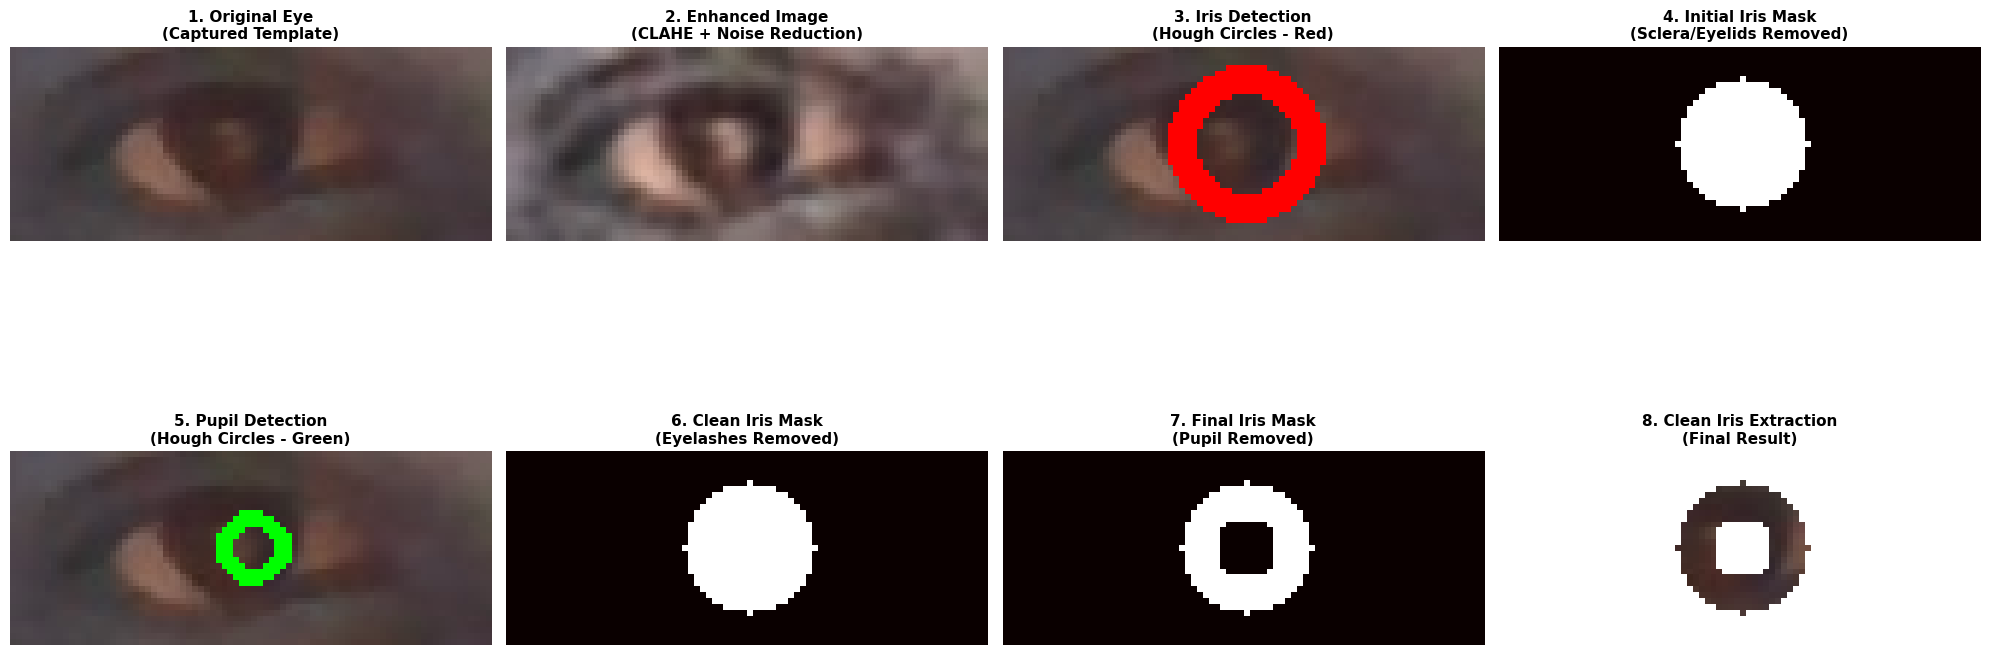


📊 DETAILED SEGMENTATION STATISTICS:
   • Initial Iris Area: 377 pixels
   • After Eyelash Removal: 377 pixels
   • Final Iris Area (Pupil Removed): 300 pixels
   • Pupil Area: 81 pixels
   • Iris/Pupil Ratio: 3.70
   • Iris Circle: center=(41, 16), radius=11
   • Pupil Circle: center=(41, 16), radius=5

✅ STEP-BY-STEP PROCESSING COMPLETED:
   1. Image Enhancement (CLAHE + Gaussian Blur)
   2. Iris Detection using Hough Circles
   3. Sclera and Eyelid Removal
   4. Eyelash Removal using Morphological Operations
   5. Pupil Detection using Hough Circles
   6. Pupil Removal from Iris Region
   7. Clean Iris Extraction with White Background

🎯 STEP-BY-STEP IRIS SEGMENTATION - RIGHT EYE


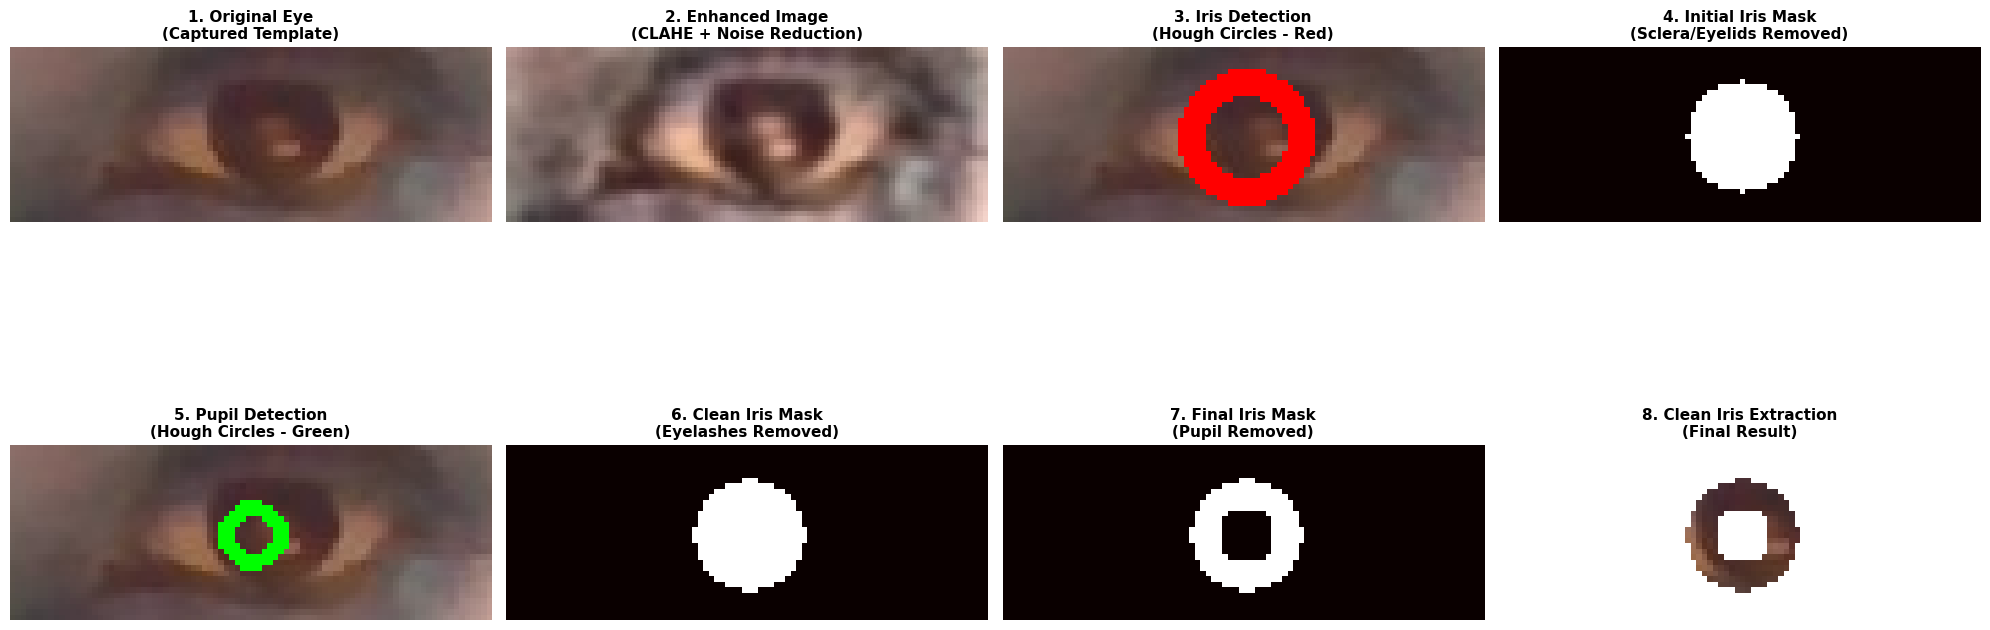


📊 DETAILED SEGMENTATION STATISTICS:
   • Initial Iris Area: 317 pixels
   • After Eyelash Removal: 325 pixels
   • Final Iris Area (Pupil Removed): 248 pixels
   • Pupil Area: 81 pixels
   • Iris/Pupil Ratio: 3.06
   • Iris Circle: center=(44, 16), radius=10
   • Pupil Circle: center=(44, 16), radius=5

✅ STEP-BY-STEP PROCESSING COMPLETED:
   1. Image Enhancement (CLAHE + Gaussian Blur)
   2. Iris Detection using Hough Circles
   3. Sclera and Eyelid Removal
   4. Eyelash Removal using Morphological Operations
   5. Pupil Detection using Hough Circles
   6. Pupil Removal from Iris Region
   7. Clean Iris Extraction with White Background

🎉 STEP-BY-STEP IRIS SEGMENTATION COMPLETED!

💾 Results saved to 'step_by_step_results' variable

🔧 Available for analysis:
   • step_by_step_results - All processing results with intermediate steps
   • Individual masks and circles for each processing stage


In [5]:
# Install required packages
!pip install opencv-python-headless scikit-image matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, morphology, measure
import os
import json

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

print("✅ Advanced Iris Segmentation Packages Loaded!")

def load_eye_templates(templates_dir="/content/eye_templates"):
    """Load eye templates from Colab file system"""
    if not os.path.exists(templates_dir):
        print(f"❌ Templates directory not found: {templates_dir}")
        return None

    info_path = os.path.join(templates_dir, "templates_info.json")
    if not os.path.exists(info_path):
        print("❌ No template information found")
        return None

    with open(info_path, 'r') as f:
        template_info = json.load(f)

    eye_templates = []

    for info in template_info:
        filepath = os.path.join(templates_dir, info['filename'])
        if os.path.exists(filepath):
            eye_img = cv2.imread(filepath)
            if eye_img is not None:
                eye_templates.append({
                    'type': info['type'],
                    'image': eye_img,
                    'bbox': info['bbox'],
                    'filename': info['filename']
                })
                print(f"✅ Loaded: {info['filename']} ({info['type']} eye)")
            else:
                print(f"❌ Failed to load: {info['filename']}")
        else:
            print(f"❌ File not found: {info['filename']}")

    return eye_templates

class StepByStepIrisProcessor:
    def __init__(self):
        print("🔧 Initializing Step-by-Step Iris Processor...")

    def enhance_image(self, eye_image):
        """Step 1: Enhance image for better processing"""
        # Convert to LAB color space
        lab = cv2.cvtColor(eye_image, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)

        # Apply CLAHE to L channel
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        l_enhanced = clahe.apply(l)

        # Merge back
        lab_enhanced = cv2.merge([l_enhanced, a, b])
        enhanced = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2BGR)

        # Apply gentle Gaussian blur
        enhanced = cv2.GaussianBlur(enhanced, (3, 3), 0)

        return enhanced

    def detect_iris_region_hough(self, enhanced_image):
        """Step 2: Detect iris region using Hough Circles (remove sclera/eyelids)"""
        gray = cv2.cvtColor(enhanced_image, cv2.COLOR_BGR2GRAY)

        # Detect circles using Hough Transform
        circles = cv2.HoughCircles(
            gray,
            cv2.HOUGH_GRADIENT,
            dp=1.2,
            minDist=gray.shape[0] // 2,
            param1=50,
            param2=30,
            minRadius=gray.shape[0] // 8,
            maxRadius=gray.shape[0] // 2
        )

        iris_mask = np.zeros(gray.shape, dtype=np.uint8)
        iris_circle = None

        if circles is not None:
            circles = np.round(circles[0, :]).astype("int")
            # Take the first (most prominent) circle
            x, y, r = circles[0]
            iris_circle = (x, y, r)

            # Create circular mask for iris
            cv2.circle(iris_mask, (x, y), r, 255, -1)
            print(f"   ✅ Iris detected: center=({x}, {y}), radius={r}")
        else:
            # Fallback: use adaptive method
            print("   ⚠️  Hough Circles failed, using adaptive method")
            h, w = gray.shape
            center_x, center_y = w // 2, h // 2
            radius = min(h, w) // 3
            iris_circle = (center_x, center_y, radius)
            cv2.circle(iris_mask, (center_x, center_y), radius, 255, -1)

        return iris_mask, iris_circle

    def remove_eyelashes_eyelids(self, iris_mask, enhanced_image):
        """Step 3: Remove eyelashes and eyelids using morphological operations"""
        # Create kernel for morphological operations
        kernel = np.ones((5, 5), np.uint8)

        # Remove small noise (eyelashes)
        cleaned = cv2.morphologyEx(iris_mask, cv2.MORPH_OPEN, kernel)

        # Fill small holes
        cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

        # Keep only the largest connected component
        contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            final_mask = np.zeros_like(iris_mask)
            cv2.drawContours(final_mask, [largest_contour], -1, 255, -1)

            # Fit ellipse for smooth shape
            if len(largest_contour) >= 5:
                ellipse = cv2.fitEllipse(largest_contour)
                ellipse_mask = np.zeros_like(iris_mask)
                cv2.ellipse(ellipse_mask, ellipse, 255, -1)
                return ellipse_mask

        return cleaned

    def detect_pupil_region(self, enhanced_image, iris_circle):
        """Step 4: Detect pupil inside the iris region"""
        gray = cv2.cvtColor(enhanced_image, cv2.COLOR_BGR2GRAY)

        if iris_circle is None:
            return np.zeros_like(gray), None

        x_iris, y_iris, r_iris = iris_circle

        # Create ROI around iris for pupil detection
        iris_roi = gray[max(0, y_iris - r_iris):min(gray.shape[0], y_iris + r_iris),
                        max(0, x_iris - r_iris):min(gray.shape[1], x_iris + r_iris)]

        if iris_roi.size == 0:
            return np.zeros_like(gray), None

        # Detect pupil using Hough Circles on iris ROI
        pupil_circles = cv2.HoughCircles(
            iris_roi,
            cv2.HOUGH_GRADIENT,
            dp=1.2,
            minDist=r_iris // 2,
            param1=30,
            param2=20,
            minRadius=max(5, r_iris // 8),
            maxRadius=r_iris // 3
        )

        pupil_mask = np.zeros(gray.shape, dtype=np.uint8)
        pupil_circle = None

        if pupil_circles is not None:
            pupil_circles = np.round(pupil_circles[0, :]).astype("int")
            x_pupil, y_pupil, r_pupil = pupil_circles[0]

            # Convert to global coordinates
            x_global = x_iris - r_iris + x_pupil
            y_global = y_iris - r_iris + y_pupil
            pupil_circle = (x_global, y_global, r_pupil)

            cv2.circle(pupil_mask, (x_global, y_global), r_pupil, 255, -1)
            print(f"   ✅ Pupil detected: center=({x_global}, {y_global}), radius={r_pupil}")
        else:
            # Fallback: assume pupil is in center of iris
            print("   ⚠️  Pupil Hough Circles failed, using center method")
            pupil_radius = max(5, r_iris // 4)
            pupil_circle = (x_iris, y_iris, pupil_radius)
            cv2.circle(pupil_mask, (x_iris, y_iris), pupil_radius, 255, -1)

        return pupil_mask, pupil_circle

    def remove_pupil_from_iris(self, iris_mask, pupil_mask):
        """Step 5: Remove pupil from iris mask"""
        final_iris_mask = iris_mask.copy()
        final_iris_mask[pupil_mask == 255] = 0

        # Clean up the mask after pupil removal
        kernel = np.ones((3, 3), np.uint8)
        final_iris_mask = cv2.morphologyEx(final_iris_mask, cv2.MORPH_CLOSE, kernel)

        return final_iris_mask

    def extract_clean_iris_region(self, original_image, final_iris_mask):
        """Step 6: Extract clean iris region on white background"""
        clean_iris = np.ones_like(original_image) * 255  # White background
        clean_iris[final_iris_mask == 255] = original_image[final_iris_mask == 255]

        return clean_iris

    def process_eye_step_by_step(self, eye_template):
        """Complete step-by-step processing pipeline"""
        print(f"\n🔍 Processing {eye_template['type']} eye...")

        original_image = eye_template['image']

        print("   Step 1: Image Enhancement")
        enhanced = self.enhance_image(original_image)

        print("   Step 2: Iris Region Detection (Remove Sclera/Eyelids)")
        iris_mask, iris_circle = self.detect_iris_region_hough(enhanced)

        print("   Step 3: Eyelash and Eyelid Removal")
        clean_iris_mask = self.remove_eyelashes_eyelids(iris_mask, enhanced)

        print("   Step 4: Pupil Detection")
        pupil_mask, pupil_circle = self.detect_pupil_region(enhanced, iris_circle)

        print("   Step 5: Pupil Removal from Iris")
        final_iris_mask = self.remove_pupil_from_iris(clean_iris_mask, pupil_mask)

        print("   Step 6: Clean Iris Extraction")
        clean_iris = self.extract_clean_iris_region(original_image, final_iris_mask)

        return {
            'type': eye_template['type'],
            'original': original_image,
            'enhanced': enhanced,
            'initial_iris_mask': iris_mask,
            'clean_iris_mask': clean_iris_mask,
            'pupil_mask': pupil_mask,
            'final_iris_mask': final_iris_mask,
            'clean_iris': clean_iris,
            'iris_circle': iris_circle,
            'pupil_circle': pupil_circle,
            'filename': eye_template['filename']
        }

def display_step_by_step_results(results):
    """Display comprehensive step-by-step results"""
    for result in results:
        print(f"\n" + "="*70)
        print(f"🎯 STEP-BY-STEP IRIS SEGMENTATION - {result['type'].upper()} EYE")
        print("="*70)

        # Convert images for display
        original_rgb = cv2.cvtColor(result['original'], cv2.COLOR_BGR2RGB)
        enhanced_rgb = cv2.cvtColor(result['enhanced'], cv2.COLOR_BGR2RGB)
        clean_iris_rgb = cv2.cvtColor(result['clean_iris'], cv2.COLOR_BGR2RGB)

        # Create overlays
        iris_overlay = original_rgb.copy()
        if result['iris_circle']:
            x, y, r = result['iris_circle']
            cv2.circle(iris_overlay, (x, y), r, (255, 0, 0), 3)  # Red circle for iris

        pupil_overlay = original_rgb.copy()
        if result['pupil_circle']:
            x, y, r = result['pupil_circle']
            cv2.circle(pupil_overlay, (x, y), r, (0, 255, 0), 2)  # Green circle for pupil

        combined_overlay = original_rgb.copy()
        if result['iris_circle'] and result['pupil_circle']:
            x_i, y_i, r_i = result['iris_circle']
            x_p, y_p, r_p = result['pupil_circle']
            cv2.circle(combined_overlay, (x_i, y_i), r_i, (255, 0, 0), 3)
            cv2.circle(combined_overlay, (x_p, y_p), r_p, (0, 255, 0), 2)

        # Create comprehensive visualization
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))

        # Row 1: Processing Steps
        axes[0, 0].imshow(original_rgb)
        axes[0, 0].set_title('1. Original Eye\n(Captured Template)', fontweight='bold', fontsize=11)
        axes[0, 0].axis('off')

        axes[0, 1].imshow(enhanced_rgb)
        axes[0, 1].set_title('2. Enhanced Image\n(CLAHE + Noise Reduction)', fontweight='bold', fontsize=11)
        axes[0, 1].axis('off')

        axes[0, 2].imshow(iris_overlay)
        axes[0, 2].set_title('3. Iris Detection\n(Hough Circles - Red)', fontweight='bold', fontsize=11)
        axes[0, 2].axis('off')

        axes[0, 3].imshow(result['initial_iris_mask'], cmap='hot')
        axes[0, 3].set_title('4. Initial Iris Mask\n(Sclera/Eyelids Removed)', fontweight='bold', fontsize=11)
        axes[0, 3].axis('off')

        # Row 2: Refinement Steps
        axes[1, 0].imshow(pupil_overlay)
        axes[1, 0].set_title('5. Pupil Detection\n(Hough Circles - Green)', fontweight='bold', fontsize=11)
        axes[1, 0].axis('off')

        axes[1, 1].imshow(result['clean_iris_mask'], cmap='hot')
        axes[1, 1].set_title('6. Clean Iris Mask\n(Eyelashes Removed)', fontweight='bold', fontsize=11)
        axes[1, 1].axis('off')

        axes[1, 2].imshow(result['final_iris_mask'], cmap='hot')
        axes[1, 2].set_title('7. Final Iris Mask\n(Pupil Removed)', fontweight='bold', fontsize=11)
        axes[1, 2].axis('off')

        axes[1, 3].imshow(clean_iris_rgb)
        axes[1, 3].set_title('8. Clean Iris Extraction\n(Final Result)', fontweight='bold', fontsize=11)
        axes[1, 3].axis('off')

        plt.tight_layout()
        plt.show()

        # Detailed Statistics
        initial_iris_area = np.sum(result['initial_iris_mask'] == 255)
        clean_iris_area = np.sum(result['clean_iris_mask'] == 255)
        final_iris_area = np.sum(result['final_iris_mask'] == 255)
        pupil_area = np.sum(result['pupil_mask'] == 255)

        print(f"\n📊 DETAILED SEGMENTATION STATISTICS:")
        print(f"   • Initial Iris Area: {initial_iris_area:,} pixels")
        print(f"   • After Eyelash Removal: {clean_iris_area:,} pixels")
        print(f"   • Final Iris Area (Pupil Removed): {final_iris_area:,} pixels")
        print(f"   • Pupil Area: {pupil_area:,} pixels")
        print(f"   • Iris/Pupil Ratio: {final_iris_area/(pupil_area + 1e-6):.2f}")

        if result['iris_circle']:
            x, y, r = result['iris_circle']
            print(f"   • Iris Circle: center=({x}, {y}), radius={r}")
        if result['pupil_circle']:
            x, y, r = result['pupil_circle']
            print(f"   • Pupil Circle: center=({x}, {y}), radius={r}")

        print(f"\n✅ STEP-BY-STEP PROCESSING COMPLETED:")
        steps = [
            "Image Enhancement (CLAHE + Gaussian Blur)",
            "Iris Detection using Hough Circles",
            "Sclera and Eyelid Removal",
            "Eyelash Removal using Morphological Operations",
            "Pupil Detection using Hough Circles",
            "Pupil Removal from Iris Region",
            "Clean Iris Extraction with White Background"
        ]
        for i, step in enumerate(steps, 1):
            print(f"   {i}. {step}")

# MAIN EXECUTION
print("🚀 Starting Step-by-Step Advanced Iris Segmentation")
print("="*60)

# Load eye templates from file system
print("📁 Loading eye templates from Colab file system...")
eye_templates = load_eye_templates()

if eye_templates:
    print(f"✅ Successfully loaded {len(eye_templates)} eye template(s)")

    # Initialize processor
    processor = StepByStepIrisProcessor()
    results = []

    print(f"\n🔬 Processing {len(eye_templates)} template(s) with step-by-step method...")
    for template in eye_templates:
        result = processor.process_eye_step_by_step(template)
        results.append(result)

    # Display comprehensive results
    print(f"\n📊 Generating step-by-step visualization...")
    display_step_by_step_results(results)

    print("\n" + "="*70)
    print("🎉 STEP-BY-STEP IRIS SEGMENTATION COMPLETED!")
    print("="*70)

    # Save processed results
    global step_by_step_results
    step_by_step_results = results
    print(f"\n💾 Results saved to 'step_by_step_results' variable")

else:
    print("❌ No eye templates found in file system!")
    print("💡 Please run Cell 1 first to capture and save eye templates")

print("\n🔧 Available for analysis:")
print("   • step_by_step_results - All processing results with intermediate steps")
print("   • Individual masks and circles for each processing stage")